# Import + Mount Drive

In [ ]:
import os
import re
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import nltk
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Load Data

In [ ]:
data_path = '/content/drive/MyDrive/DSO 560/Project /cleaned_data'

games_description = pd.read_csv(os.path.join(data_path, 'games_description_final.csv'))
games_ranking = pd.read_csv(os.path.join(data_path, 'games_ranking_final.csv'))
steam_game_reviews = pd.read_csv(os.path.join(data_path, 'steam_game_reviews_final.csv'))

print(games_description.shape)
print(games_ranking.shape)
print(steam_game_reviews.shape)

display(games_description.head())
display(steam_game_reviews.head())

(290, 16)
(672, 4)
(383228, 18)


,name,short_description,long_description,genres,minimum_system_requirement,recommend_system_requirement,release_date,developer,publisher,overall_player_rating,number_of_reviews_from_purchased_people,number_of_english_reviews,link,release_date_parsed,genre_list,n_genres
0,Black Myth: Wukong,Black Myth: Wukong is an action RPG rooted in ...,About This Game Black Myth: Wukong is an actio...,"['Mythology', 'Action RPG', 'Action', 'RPG', '...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"19 Aug, 2024",['Game Science'],['Game Science'],Overwhelmingly Positive,0,51931,https://store.steampowered.com/app/2358720/Bla...,2024-08-19,"[""['Mythology'"", ""'Action RPG'"", ""'Action'"", ""...",20
1,Counter-Strike 2,"For over two decades, Counter-Strike has offer...","About This Game For over two decades, Counter-...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","['OS: Windows® 10', 'Processor: 4 hardware CPU...","['OS: Windows® 10', 'Processor: 4 hardware CPU...","21 Aug, 2012",['Valve'],['Valve'],Very Positive,0,2258990,https://store.steampowered.com/app/730/Counter...,2012-08-21,"[""['FPS'"", ""'Shooter'"", ""'Multiplayer'"", ""'Com...",20
2,"Warhammer 40,000: Space Marine 2",Embody the superhuman skill and brutality of a...,About This Game Embody the superhuman skill an...,"['Warhammer 40K', 'Action', 'Third-Person Shoo...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"9 Sep, 2024",['Saber Interactive'],['Focus Entertainment'],Very Positive,0,51920,https://store.steampowered.com/app/2183900/War...,2024-09-09,"[""['Warhammer 40K'"", ""'Action'"", ""'Third-Perso...",20
3,Cyberpunk 2077,"Cyberpunk 2077 is an open-world, action-advent...",About This Game Cyberpunk 2077 is an open-worl...,"['Cyberpunk', 'Open World', 'Nudity', 'RPG', '...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"10 Dec, 2020",['CD PROJEKT RED'],['CD PROJEKT RED'],Very Positive,0,324124,https://store.steampowered.com/app/1091500/Cyb...,2020-12-10,"[""['Cyberpunk'"", ""'Open World'"", ""'Nudity'"", ""...",20
4,ELDEN RING,THE CRITICALLY ACCLAIMED FANTASY ACTION RPG. R...,About This Game THE CRITICALLY ACCLAIMED FANTA...,"['Souls-like', 'Dark Fantasy', 'Open World', '...",['Requires a 64-bit processor and operating sy...,['Requires a 64-bit processor and operating sy...,"25 Feb, 2022","['FromSoftware, Inc.']","['FromSoftware, Inc.', 'Bandai Namco Entertain...",Very Positive,0,491741,https://store.steampowered.com/app/1245620/ELD...,2022-02-25,"[""['Souls-like'"", ""'Dark Fantasy'"", ""'Open Wor...",20


,game_name,username_clean,products_in_account,recommendation,is_recommended,hours_played,helpful,funny,review_day,review_month,review_year,review_char_len,review_word_len,review,is_hours_outlier,is_len_outlier,is_helpful_outlier,is_products_outlier
0,"Warhammer 40,000: Space Marine 2",Sentinowl,224,Recommended,1,39.9,1152,13,14,September,NaN,616,117,The game itself is also super fun. The PvP and...,0,0,1,0
1,"Warhammer 40,000: Space Marine 2",userpig,248,Recommended,1,91.5,712,116,13,September,NaN,1338,239,Never cared much about Warhammer until this ga...,0,0,1,0
2,"Warhammer 40,000: Space Marine 2",Imparat0r,112,Recommended,1,43.3,492,33,14,September,NaN,774,126,A salute to all the fallen battle brothers who...,0,0,0,0
3,"Warhammer 40,000: Space Marine 2",Fattest_falcon,0,Recommended,1,16.8,661,15,14,September,NaN,86,18,this game feels like it was made in the mid 20...,0,0,1,0
4,"Warhammer 40,000: Space Marine 2",Jek,410,Recommended,1,24.0,557,4,12,September,NaN,97,19,Reminds me of something I've lost. A genuine g...,0,0,0,0


# Merge + Label

In [ ]:
df = steam_game_reviews.merge(
    games_description[['name', 'genres']],
    left_on='game_name',
    right_on='name',
    how='left'
)

df = df.dropna(subset=['review', 'recommendation']).copy()

df['label'] = df['recommendation'].map({
    'Recommended': 1,
    'Not Recommended': 0
})

df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

print(df.shape)
print(df['label'].value_counts())
display(df[['game_name', 'recommendation', 'label', 'review', 'genres']].head())

(383228, 21)
label
1    316340
0     66888
Name: count, dtype: int64


,game_name,recommendation,label,review,genres
0,"Warhammer 40,000: Space Marine 2",Recommended,1,The game itself is also super fun. The PvP and...,"['Warhammer 40K', 'Action', 'Third-Person Shoo..."
1,"Warhammer 40,000: Space Marine 2",Recommended,1,Never cared much about Warhammer until this ga...,"['Warhammer 40K', 'Action', 'Third-Person Shoo..."
2,"Warhammer 40,000: Space Marine 2",Recommended,1,A salute to all the fallen battle brothers who...,"['Warhammer 40K', 'Action', 'Third-Person Shoo..."
3,"Warhammer 40,000: Space Marine 2",Recommended,1,this game feels like it was made in the mid 20...,"['Warhammer 40K', 'Action', 'Third-Person Shoo..."
4,"Warhammer 40,000: Space Marine 2",Recommended,1,Reminds me of something I've lost. A genuine g...,"['Warhammer 40K', 'Action', 'Third-Person Shoo..."


# Clean Text

In [ ]:
stop_words = set(stopwords.words('english'))

extra_stopwords = {
    'game', 'games', 'play', 'played', 'playing',
    'steam', 'really', 'also', 'get', 'got', 'like'
}

stop_words = stop_words.union(extra_stopwords)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

df['cleaned_text'] = df['review'].astype(str).apply(clean_text)
df = df[df['cleaned_text'].str.len() > 0].copy()

df['review_length'] = df['review'].astype(str).str.len()
df['word_count'] = df['cleaned_text'].str.split().str.len()

display(df[['review', 'cleaned_text', 'word_count']].head())
display(df[['review_length', 'word_count']].describe())

,review,cleaned_text,word_count
0,The game itself is also super fun. The PvP and...,super fun pvp campaign joy actions feel delibe...,43
1,Never cared much about Warhammer until this ga...,never cared much warhammer showed error ways m...,115
2,A salute to all the fallen battle brothers who...,salute fallen battle brothers years waiting ev...,67
3,this game feels like it was made in the mid 20...,feels made mid early good way,6
4,Reminds me of something I've lost. A genuine g...,reminds something lost genuine good simple sho...,8


,review_length,word_count
count,379828.000000,379828.000000
mean,437.262269,36.233295
std,887.173684,74.861021
min,8.000000,1.000000
25%,48.000000,4.000000
50%,126.000000,10.000000
75%,408.000000,33.000000
max,8573.000000,2000.000000


**Interpretation:**  
After cleaning, the dataset contains 379,828 usable reviews. The average cleaned review has about 36 words, but the distribution is highly skewed, meaning many reviews are short while a smaller number of users write very detailed feedback. This supports using text analytics because reviews contain rich but unevenly structured information.

# VADER Sentiment

In [ ]:
sia = SentimentIntensityAnalyzer()

df['vader_score'] = df['review'].astype(str).apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def vader_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_score'].apply(vader_sentiment)

df['vader_binary'] = df['vader_sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

vader_eval = df.dropna(subset=['vader_binary']).copy()
vader_eval['vader_binary'] = vader_eval['vader_binary'].astype(int)

vader_accuracy = accuracy_score(vader_eval['label'], vader_eval['vader_binary'])
vader_f1 = f1_score(vader_eval['label'], vader_eval['vader_binary'])

print("VADER Results")
print("Accuracy:", vader_accuracy)
print("F1-score:", vader_f1)

display(df[['review', 'recommendation', 'vader_score', 'vader_sentiment']].head())

VADER Results
Accuracy: 0.7916181041181041
F1-score: 0.8707851211671799


,review,recommendation,vader_score,vader_sentiment
0,The game itself is also super fun. The PvP and...,Recommended,0.9753,Positive
1,Never cared much about Warhammer until this ga...,Recommended,-0.9064,Negative
2,A salute to all the fallen battle brothers who...,Recommended,0.9020,Positive
3,this game feels like it was made in the mid 20...,Recommended,0.8338,Positive
4,Reminds me of something I've lost. A genuine g...,Recommended,0.7003,Positive


**Interpretation:**  
VADER achieves an accuracy of about 79.2% and an F1-score of about 87.1% when compared with user recommendation labels. This suggests that rule-based sentiment analysis captures general sentiment patterns, but it may miss more complex gaming-specific language such as sarcasm, mixed opinions, or reviews that recommend a game while still criticizing it.

# Sentiment Visualizations

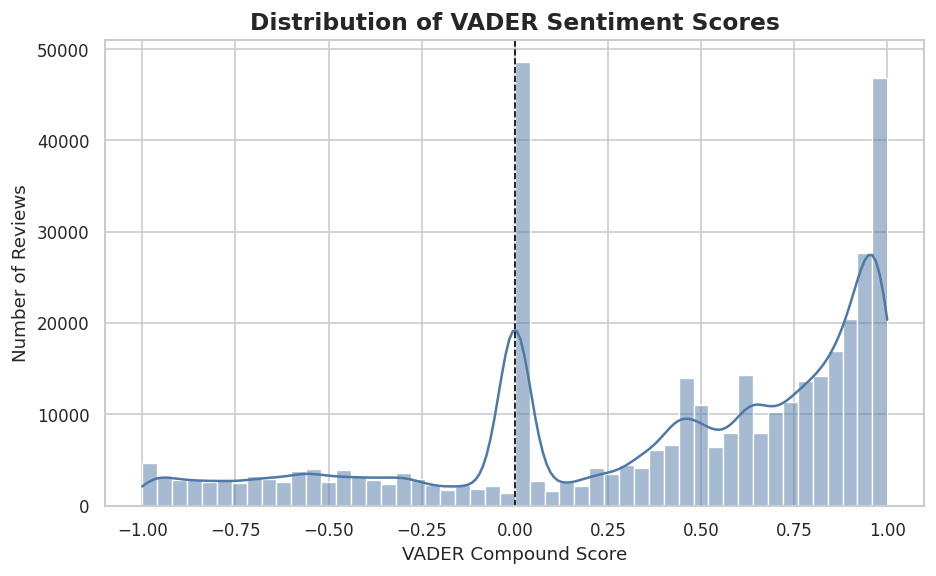

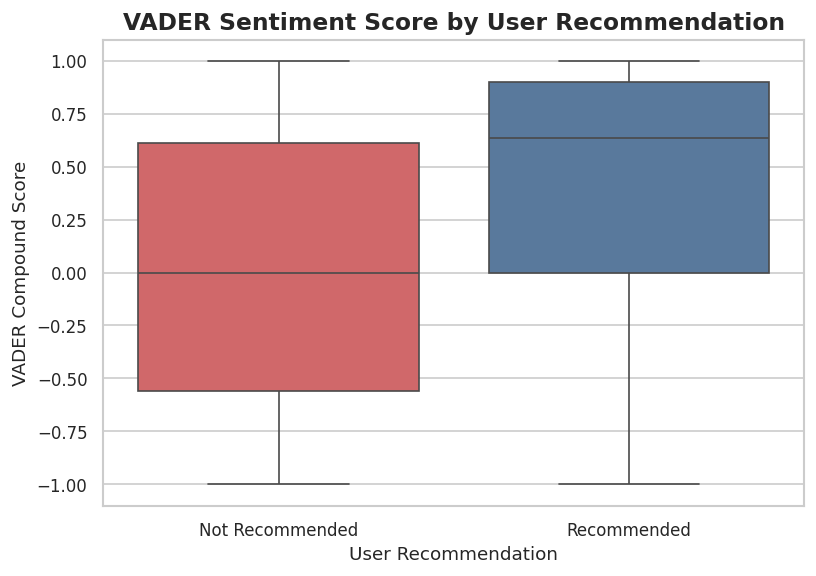

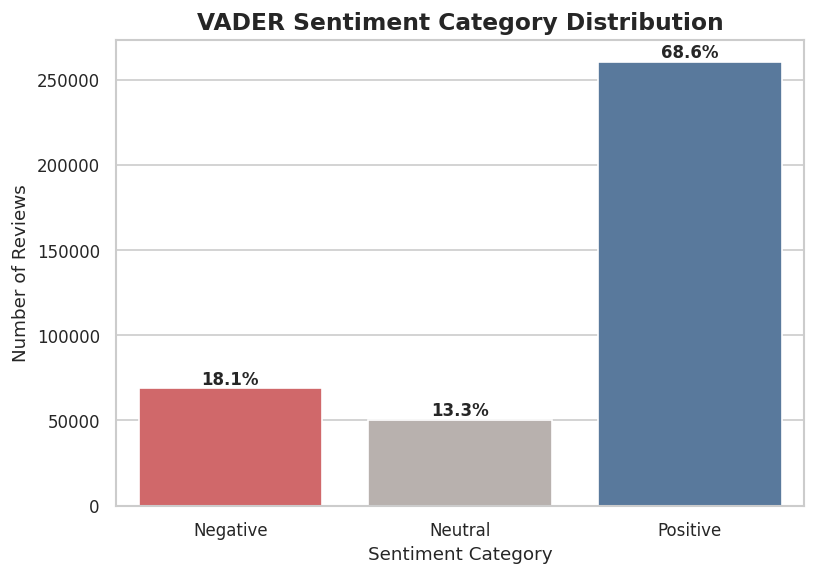

In [ ]:
palette_sentiment = {
    'Negative': '#E15759',
    'Neutral': '#BAB0AC',
    'Positive': '#4E79A7'
}

plt.figure(figsize=(8, 5))

sns.histplot(
    df['vader_score'],
    bins=50,
    kde=True,
    color='#4E79A7',
    edgecolor='white'
)

plt.axvline(0, linestyle='--', linewidth=1, color='black')
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('VADER Compound Score')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x='recommendation',
    y='vader_score',
    hue='recommendation',
    order=['Not Recommended', 'Recommended'],
    palette={
        'Not Recommended': '#E15759',
        'Recommended': '#4E79A7'
    },
    legend=False
)

plt.title('VADER Sentiment Score by User Recommendation')
plt.xlabel('User Recommendation')
plt.ylabel('VADER Compound Score')
plt.tight_layout()
plt.show()


sentiment_counts = df['vader_sentiment'].value_counts().reindex(
    ['Negative', 'Neutral', 'Positive']
).reset_index()

sentiment_counts.columns = ['Sentiment', 'Count']
sentiment_counts['Percent'] = sentiment_counts['Count'] / sentiment_counts['Count'].sum()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=sentiment_counts,
    x='Sentiment',
    y='Count',
    hue='Sentiment',
    palette=palette_sentiment,
    legend=False
)

plt.title('VADER Sentiment Category Distribution')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Reviews')

for i, row in sentiment_counts.iterrows():
    ax.text(
        i,
        row['Count'],
        f"{row['Percent']:.1%}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

**Interpretation:**  
The sentiment distribution is skewed toward positive sentiment, which aligns with the high share of Recommended reviews. However, the negative tail remains important because it captures dissatisfaction signals that can help identify product improvement opportunities.

# TF-IDF + Logistic Regression + SVM

In [ ]:
X_text = df['cleaned_text']
y = df['label']

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X = tfidf.fit_transform(X_text)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("TF-IDF + Logistic Regression Results")
print(classification_report(y_test, y_pred_log))

log_accuracy = accuracy_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("TF-IDF + SVM Results")
print(classification_report(y_test, y_pred_svm))

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

TF-IDF + Logistic Regression Results
              precision    recall  f1-score   support

           0       0.82      0.65      0.73     13303
           1       0.93      0.97      0.95     62663

    accuracy                           0.91     75966
   macro avg       0.87      0.81      0.84     75966
weighted avg       0.91      0.91      0.91     75966

TF-IDF + SVM Results
              precision    recall  f1-score   support

           0       0.81      0.66      0.73     13303
           1       0.93      0.97      0.95     62663

    accuracy                           0.91     75966
   macro avg       0.87      0.82      0.84     75966
weighted avg       0.91      0.91      0.91     75966



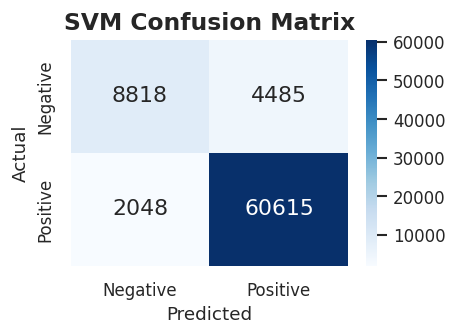

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.tight_layout()
plt.show()

# Model Comparison

In [ ]:
model_results = pd.DataFrame({
    'Model': ['VADER', 'TF-IDF + Logistic Regression', 'TF-IDF + SVM'],
    'Accuracy': [vader_accuracy, log_accuracy, svm_accuracy],
    'F1-score': [vader_f1, log_f1, svm_f1]
})

model_results_melted = model_results.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

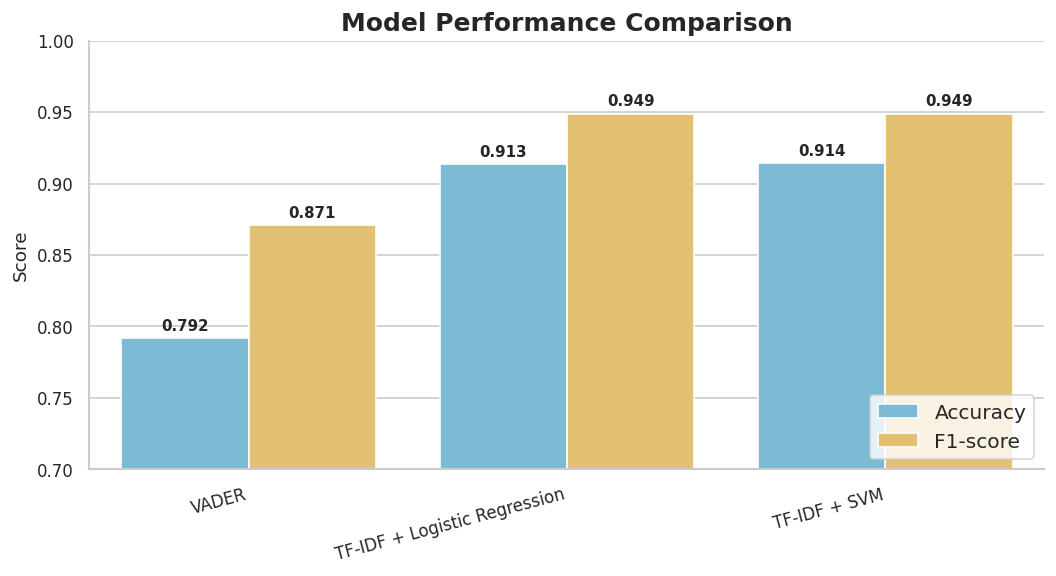

In [ ]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=model_results_melted,
    x='Model',
    y='Score',
    hue='Metric',
    palette={
        'Accuracy': '#6EC1E4',
        'F1-score': '#F6C85F'
    }
)

plt.title('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.xlabel('')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.ylim(0.7, 1.0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')

plt.legend(title='', loc='lower right', frameon=True)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**  
TF-IDF based models outperform the VADER baseline. TF-IDF + SVM performs slightly better than Logistic Regression, with accuracy around 91.4% and F1-score around 94.9%. Therefore, we use SVM as the final classifier for downstream sentiment-based analysis.

# Final Sentiment Label from SVM

In [ ]:
df['final_sentiment_label'] = svm_model.predict(X)

df['final_sentiment'] = df['final_sentiment_label'].map({
    1: 'Positive',
    0: 'Negative'
})

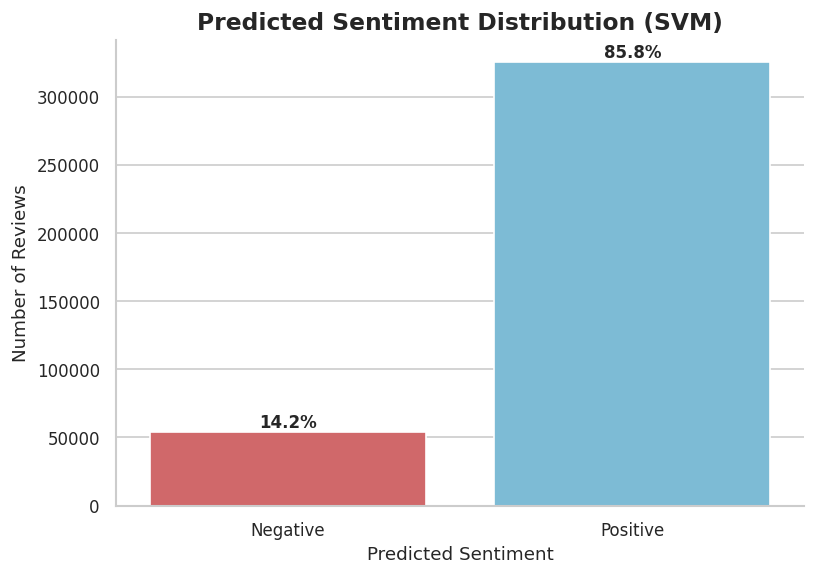

In [ ]:

palette_pred = {
    'Negative': '#E15759',
    'Positive': '#6EC1E4'
}


sentiment_model_counts = df['final_sentiment'].value_counts().reindex(['Negative', 'Positive']).reset_index()
sentiment_model_counts.columns = ['Predicted Sentiment', 'Count']
sentiment_model_counts['Percent'] = sentiment_model_counts['Count'] / sentiment_model_counts['Count'].sum()


plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=sentiment_model_counts,
    x='Predicted Sentiment',
    y='Count',
    hue='Predicted Sentiment',
    palette=palette_pred,
    legend=False
)

plt.title('Predicted Sentiment Distribution (SVM)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Number of Reviews')


for i, row in sentiment_model_counts.iterrows():
    ax.text(
        i,
        row['Count'],
        f"{row['Percent']:.1%}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**  
The SVM model predicts that most reviews are positive, while about 14.2% are negative. The negative review subset is especially valuable for this project because it helps identify the main drivers of player dissatisfaction.

# Ranking Genre

In [ ]:
ranking_genres = games_ranking[['game_name', 'genre']].drop_duplicates()

df_ranking_genre = df.merge(
    ranking_genres,
    on='game_name',
    how='left'
)

df_ranking_genre = df_ranking_genre.dropna(subset=['genre']).copy()

print("Number of ranking genres:", df_ranking_genre['genre'].nunique())
print(df_ranking_genre['genre'].value_counts())
display(df_ranking_genre[['game_name', 'genre', 'recommendation', 'vader_score', 'final_sentiment']].head())

Number of ranking genres: 6
genre
Action             206112
Adventure          150639
Role-Playing       102835
Simulation          50209
Strategy             4872
Sports & Racing      4266
Name: count, dtype: int64


,game_name,genre,recommendation,vader_score,final_sentiment
0,"Warhammer 40,000: Space Marine 2",Action,Recommended,0.9753,Positive
1,"Warhammer 40,000: Space Marine 2",Adventure,Recommended,0.9753,Positive
2,"Warhammer 40,000: Space Marine 2",Action,Recommended,-0.9064,Positive
3,"Warhammer 40,000: Space Marine 2",Adventure,Recommended,-0.9064,Positive
4,"Warhammer 40,000: Space Marine 2",Action,Recommended,0.9020,Positive


**Interpretation:**  
The ranking dataset groups games into six broad genres: Action, Adventure, Role-Playing, Simulation, Strategy, and Sports & Racing. We use these broader ranking genres for cleaner genre-level comparisons instead of the more detailed multi-label genre tags from the description dataset.

# Sentiment by Ranking Genre

In [ ]:
genre_sentiment = df_ranking_genre.groupby('genre').agg(
    avg_vader_score=('vader_score', 'mean'),
    positive_rate=('label', 'mean'),
    predicted_positive_rate=('final_sentiment_label', 'mean'),
    review_count=('review', 'count')
).reset_index()

genre_sentiment = genre_sentiment.sort_values('avg_vader_score')

display(genre_sentiment)

,genre,avg_vader_score,positive_rate,predicted_positive_rate,review_count
5,Strategy,0.157690,0.415435,0.493637,4872
0,Action,0.351176,0.780925,0.821743,206112
4,Sports & Racing,0.372359,0.731599,0.774730,4266
1,Adventure,0.391660,0.809472,0.842026,150639
2,Role-Playing,0.398419,0.830437,0.857198,102835
3,Simulation,0.450604,0.873110,0.899361,50209


**Interpretation:**  
Sentiment differs meaningfully across genres. Strategy has the lowest average sentiment score and recommendation rate, while Simulation has the strongest sentiment and recommendation performance. This suggests that player satisfaction varies by genre and that different game categories may have different pain points.

# Genre Visualization

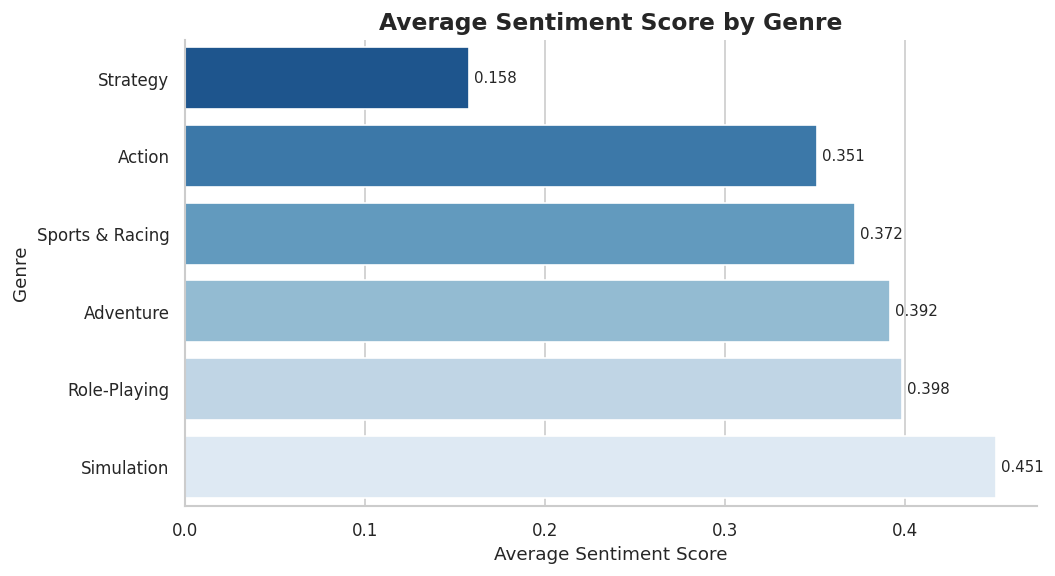

In [ ]:

genre_sentiment_sorted = genre_sentiment.sort_values('avg_vader_score')

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=genre_sentiment_sorted,
    x='avg_vader_score',
    y='genre',
    hue='genre',
    palette='Blues_r',
    legend=False
)

plt.title('Average Sentiment Score by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Average Sentiment Score')
plt.ylabel('Genre')


for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

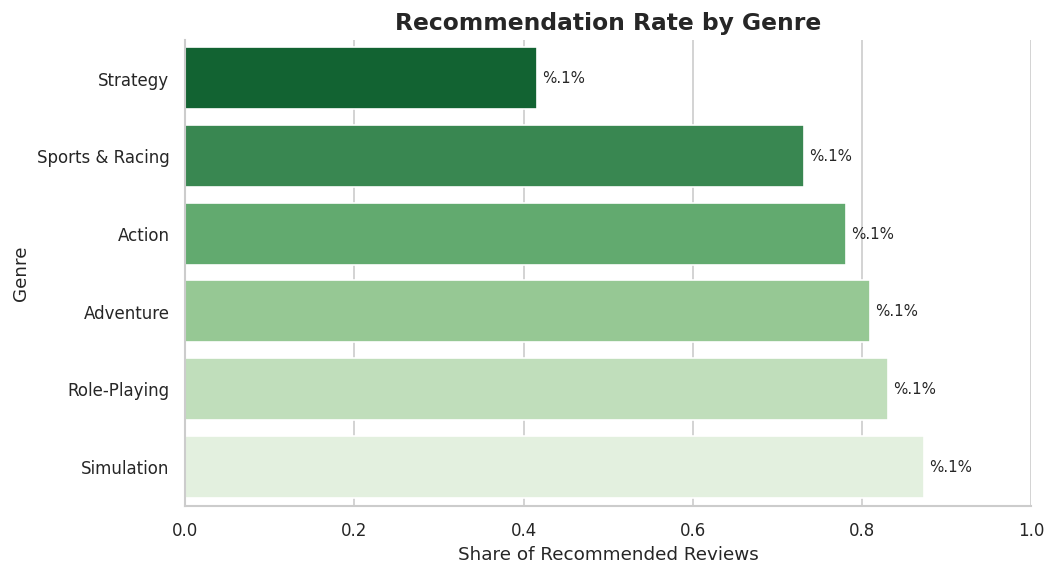

In [ ]:

genre_rate_sorted = genre_sentiment.sort_values('positive_rate')

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=genre_rate_sorted,
    x='positive_rate',
    y='genre',
    hue='genre',
    palette='Greens_r',
    legend=False
)

plt.title('Recommendation Rate by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Share of Recommended Reviews')
plt.ylabel('Genre')

plt.xlim(0, 1)


for container in ax.containers:
    ax.bar_label(container, fmt='%.1%', padding=3, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**
Both sentiment scores and recommendation rates show consistent patterns across genres.
Strategy has the lowest sentiment and recommendation performance, while Simulation performs the best.
This alignment validates our sentiment model and suggests that player satisfaction varies significantly by genre.

# LDA Topic Modeling on Negative Reviews

In [ ]:
df_neg = df_ranking_genre[df_ranking_genre['final_sentiment'] == 'Negative'].copy()

vectorizer = CountVectorizer(
    max_df=0.9,
    min_df=50,
    stop_words='english',
    max_features=5000
)

X_neg = vectorizer.fit_transform(df_neg['cleaned_text'])

lda = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)

lda.fit(X_neg)

words = vectorizer.get_feature_names_out()

topic_results = []

for topic_idx, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-12:][::-1]]
    topic_results.append({
        'Topic': f'Topic {topic_idx + 1}',
        'Top Words': ', '.join(top_words)
    })

topic_df = pd.DataFrame(topic_results)
display(topic_df)

,Topic,Top Words
0,Topic 1,"online, time, rockstar, hours, account, update..."
1,Topic 2,"free, time, content, new, warframe, grind, mon..."
2,Topic 3,"dlc, buy, money, new, price, review, fps, good..."
3,Topic 4,"time, story, good, feels, combat, feel, way, e..."
4,Topic 5,"players, server, servers, time, people, early,..."


**Interpretation:**  
The LDA model identifies five major themes in negative reviews. Based on the top words, these topics appear to reflect issues such as online/account problems, grinding or content concerns, DLC/pricing complaints, gameplay/story experience, and server/player-base issues. These themes translate unstructured negative reviews into actionable complaint categories.

Topic 1: Online / Account Issues  
Players complain about login problems, updates, and account-related issues.

Topic 2: Content & Grinding  
Players feel the game lacks content or requires excessive grinding.

Topic 3: Pricing & DLC  
Complaints about expensive DLCs or poor value for money.

Topic 4: Gameplay & Experience  
Mixed feedback about gameplay mechanics, story, or overall experience.

Topic 5: Servers & Player Base  
Issues related to servers, multiplayer experience, and player interactions.

# Assign Dominant Topic

,Topic,Review Count
0,Topic 1,21516
1,Topic 2,13303
2,Topic 3,21317
3,Topic 4,12995
4,Topic 5,14573


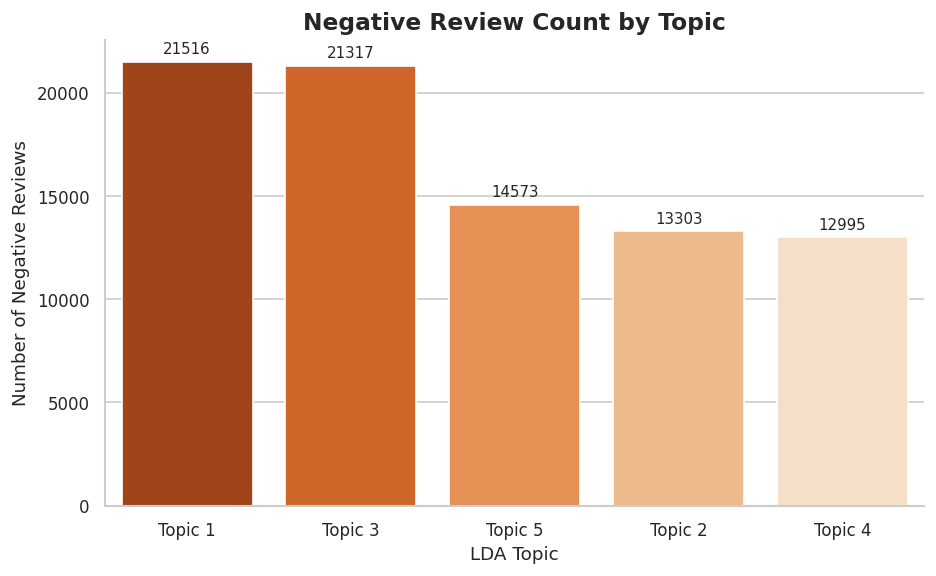

In [ ]:
topic_distribution = lda.transform(X_neg)

df_neg['dominant_topic'] = topic_distribution.argmax(axis=1) + 1

topic_counts = df_neg['dominant_topic'].value_counts().sort_index().reset_index()
topic_counts.columns = ['Topic Number', 'Review Count']

topic_counts['Topic'] = topic_counts['Topic Number'].apply(lambda x: f'Topic {x}')
topic_counts = topic_counts[['Topic', 'Review Count']]

display(topic_counts)

topic_counts_sorted = topic_counts.sort_values('Review Count', ascending=False)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=topic_counts_sorted,
    x='Topic',
    y='Review Count',
    hue='Topic',
    palette='Oranges_r',
    legend=False
)

plt.title('Negative Review Count by Topic', fontsize=14, fontweight='bold')
plt.xlabel('LDA Topic')
plt.ylabel('Number of Negative Reviews')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**  
The topic distribution shows which complaint themes appear most frequently among negative reviews. The largest topics should be prioritized because they represent the most common sources of player dissatisfaction.

# Topic by Genre

In [ ]:

topic_by_genre = df_neg.groupby(
    ['genre', 'dominant_topic']
).size().reset_index(name='count')


topic_by_genre['Topic'] = topic_by_genre['dominant_topic'].apply(
    lambda x: f'Topic {x}'
)

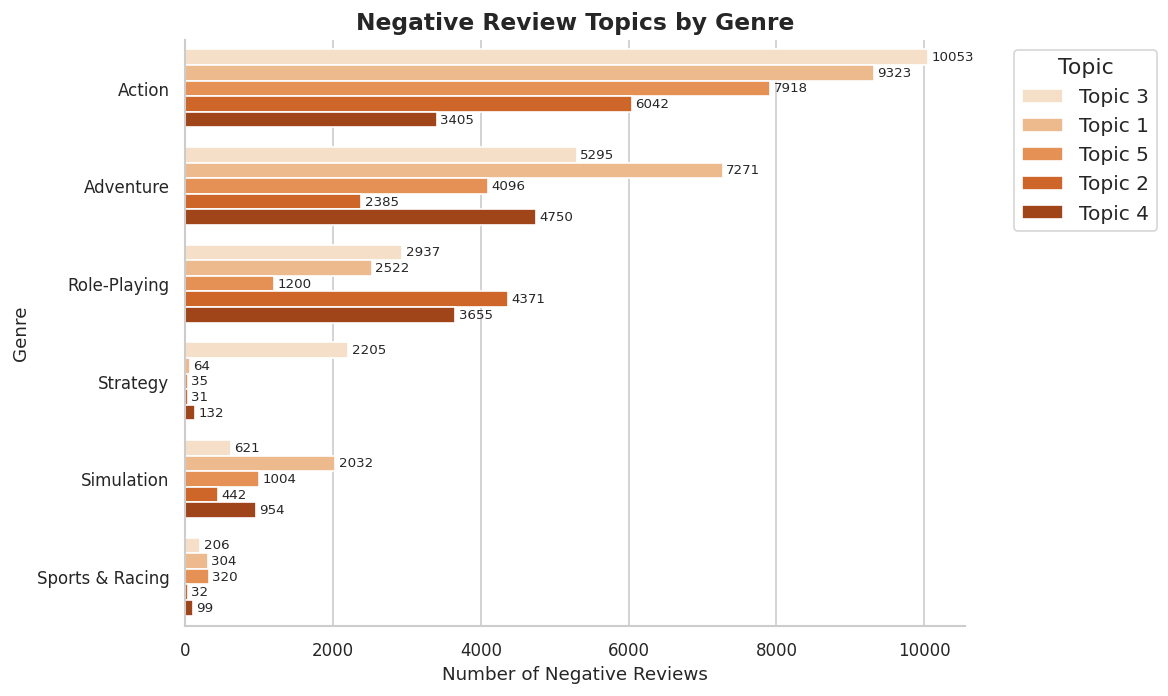

In [ ]:

topic_by_genre_sorted = topic_by_genre.sort_values('count', ascending=False)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=topic_by_genre_sorted,
    x='count',
    y='genre',
    hue='Topic',
    palette='Oranges',
)

plt.title('Negative Review Topics by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Number of Negative Reviews')
plt.ylabel('Genre')


for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=8)

plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

**Interpretation:**  
Complaint topics vary across genres, suggesting that player dissatisfaction is context-specific. Developers should not apply the same improvement strategy across all games; instead, they should prioritize fixes based on the dominant pain points within each genre.

In [ ]:
output_path = '/content/drive/MyDrive/DSO 560/Project /cleaned_data/group1_sentiment_topic_outputs/'

os.makedirs(output_path, exist_ok=True)

df_ranking_genre.to_csv(os.path.join(output_path, 'group1_processed_reviews_ranking_genre.csv'), index=False)
model_results.to_csv(os.path.join(output_path, 'model_comparison.csv'), index=False)
genre_sentiment.to_csv(os.path.join(output_path, 'ranking_genre_sentiment_summary.csv'), index=False)
topic_df.to_csv(os.path.join(output_path, 'lda_topic_words.csv'), index=False)
topic_counts.to_csv(os.path.join(output_path, 'lda_topic_counts.csv'), index=False)
topic_by_genre.to_csv(os.path.join(output_path, 'topic_by_ranking_genre.csv'), index=False)

print("Saved outputs to:", output_path)

Saved outputs to: /content/drive/MyDrive/DSO 560/Project /cleaned_data/group1_sentiment_topic_outputs/


# **Negative Reviews Across 3 Time Eras**

In [ ]:
df['review_year'] = df['review_year'].fillna(2024)

# Verify the change
print(f"Missing values in review_year: {df['review_year'].isnull().sum()}")
display(df['review_year'].value_counts().sort_index())

Missing values in review_year: 0


,count
review_year,
2010.0,54
2011.0,292
2012.0,384
2013.0,2565
2014.0,9282
2015.0,11558
2016.0,13052
2017.0,17077
2018.0,16258


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. Filter for RPG games with Negative Sentiment (based on our SVM labels)
df_rpg_neg = df_ranking_genre[(df_ranking_genre['genre'] == 'Role-Playing') & (df_ranking_genre['final_sentiment'] == 'Negative')].copy()

# 2. Define periods
def get_period(year):
    if 2010 <= year <= 2014: return '2010-2014'
    elif 2015 <= year <= 2019: return '2015-2019'
    elif 2020 <= year <= 2024: return '2020-2024'
    return None

df_rpg_neg['period'] = df_rpg_neg['review_year'].apply(get_period)
df_rpg_neg = df_rpg_neg.dropna(subset=['period'])

periods = ['2010-2014', '2015-2019', '2020-2024']
period_topics_data = {}

# 3. LDA for each period (Negative Reviews only)
for period in periods:
    period_data = df_rpg_neg[df_rpg_neg['period'] == period]
    if len(period_data) < 5:
        continue

    vectorizer = CountVectorizer(max_df=0.8, min_df=2, stop_words='english', max_features=500)
    X = vectorizer.fit_transform(period_data['cleaned_text'])

    lda = LatentDirichletAllocation(n_components=3, random_state=42) # 3 key themes per period for clarity
    lda.fit(X)

    words = vectorizer.get_feature_names_out()
    topics = []
    for topic_idx, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-10:][::-1]
        top_words = [words[i] for i in top_indices]
        top_weights = [topic[i] for i in top_indices]
        topics.append({'words': top_words, 'weights': top_weights})
    period_topics_data[period] = topics


# Output the text table for reference
topic_summary = {p: [", ".join(t['words'][:8]) for t in period_topics_data[p]] for p in period_topics_data}
display(pd.DataFrame(topic_summary, index=['Theme 1', 'Theme 2', 'Theme 3']))

,2010-2014,2015-2019,2020-2024
Theme 1,"warframe, content, new, players, weapons, year...","issues, disconnected, monster, fix, friends, c...","time, story, good, world, combat, fun, way, en..."
Theme 2,"time, players, hours, pay, warframe, going, we...","content, new, bungie, destiny, time, pvp, good...","content, new, time, bungie, destiny, players, ..."
Theme 3,"account, warframe, time, support, new, people,...","time, players, warframe, new, weapons, people,...","free, dlc, diablo, buy, blizzard, money, accou..."


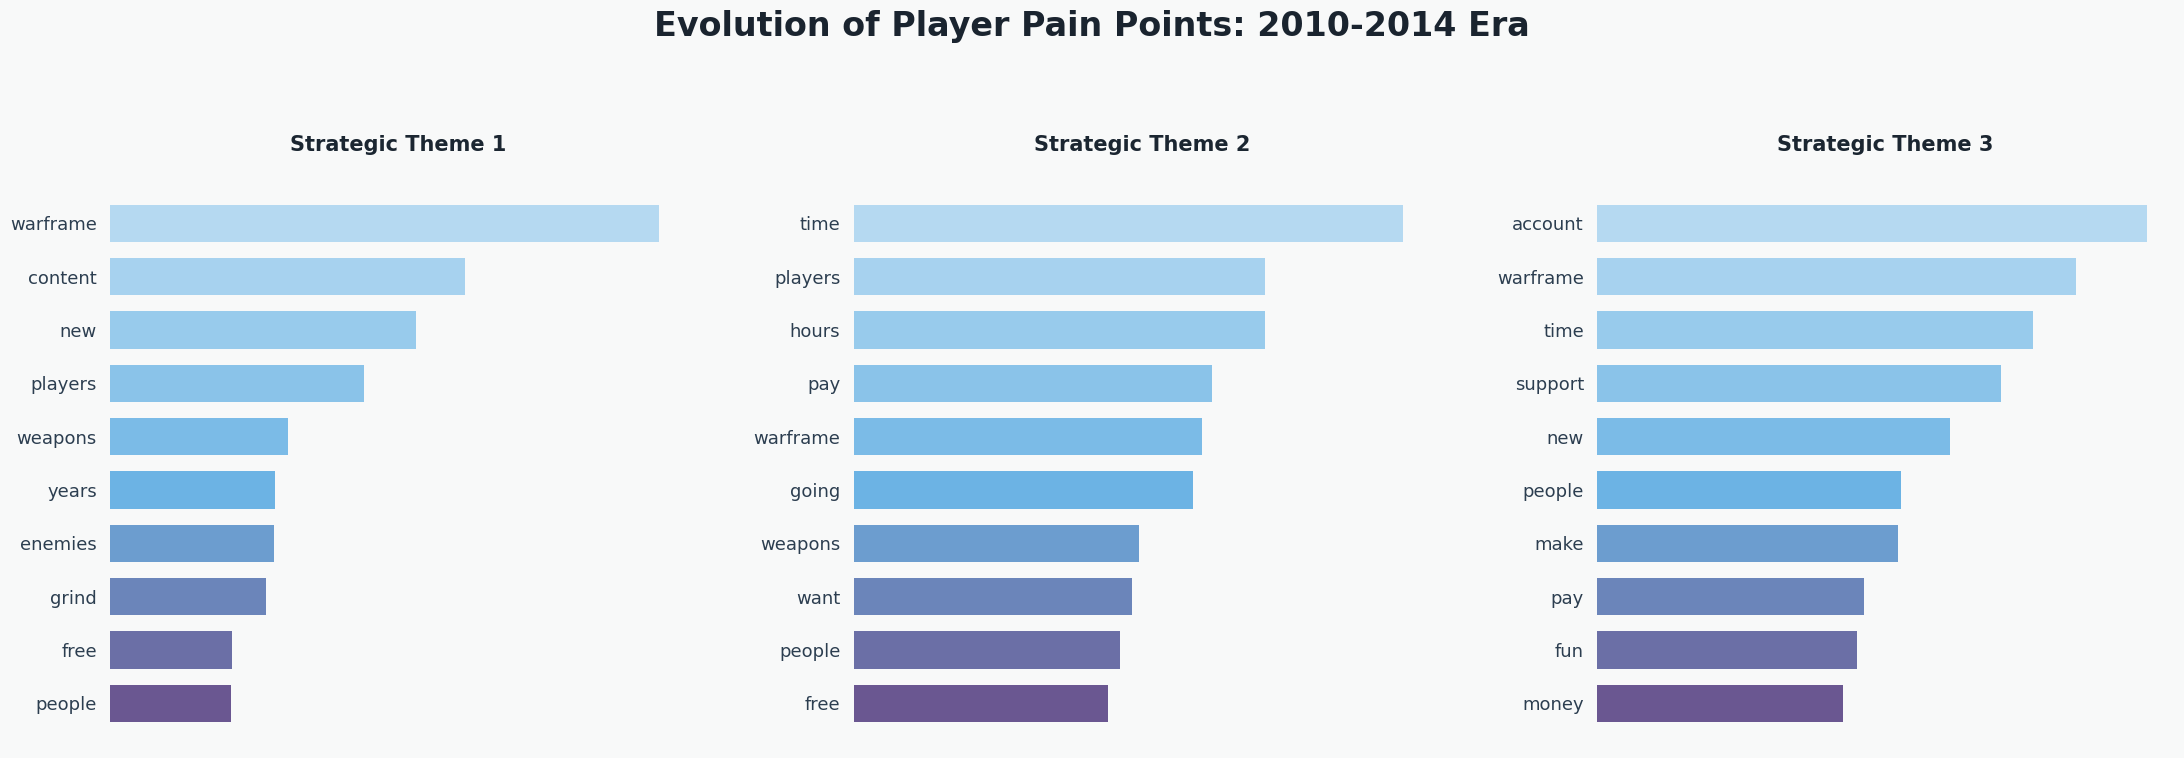

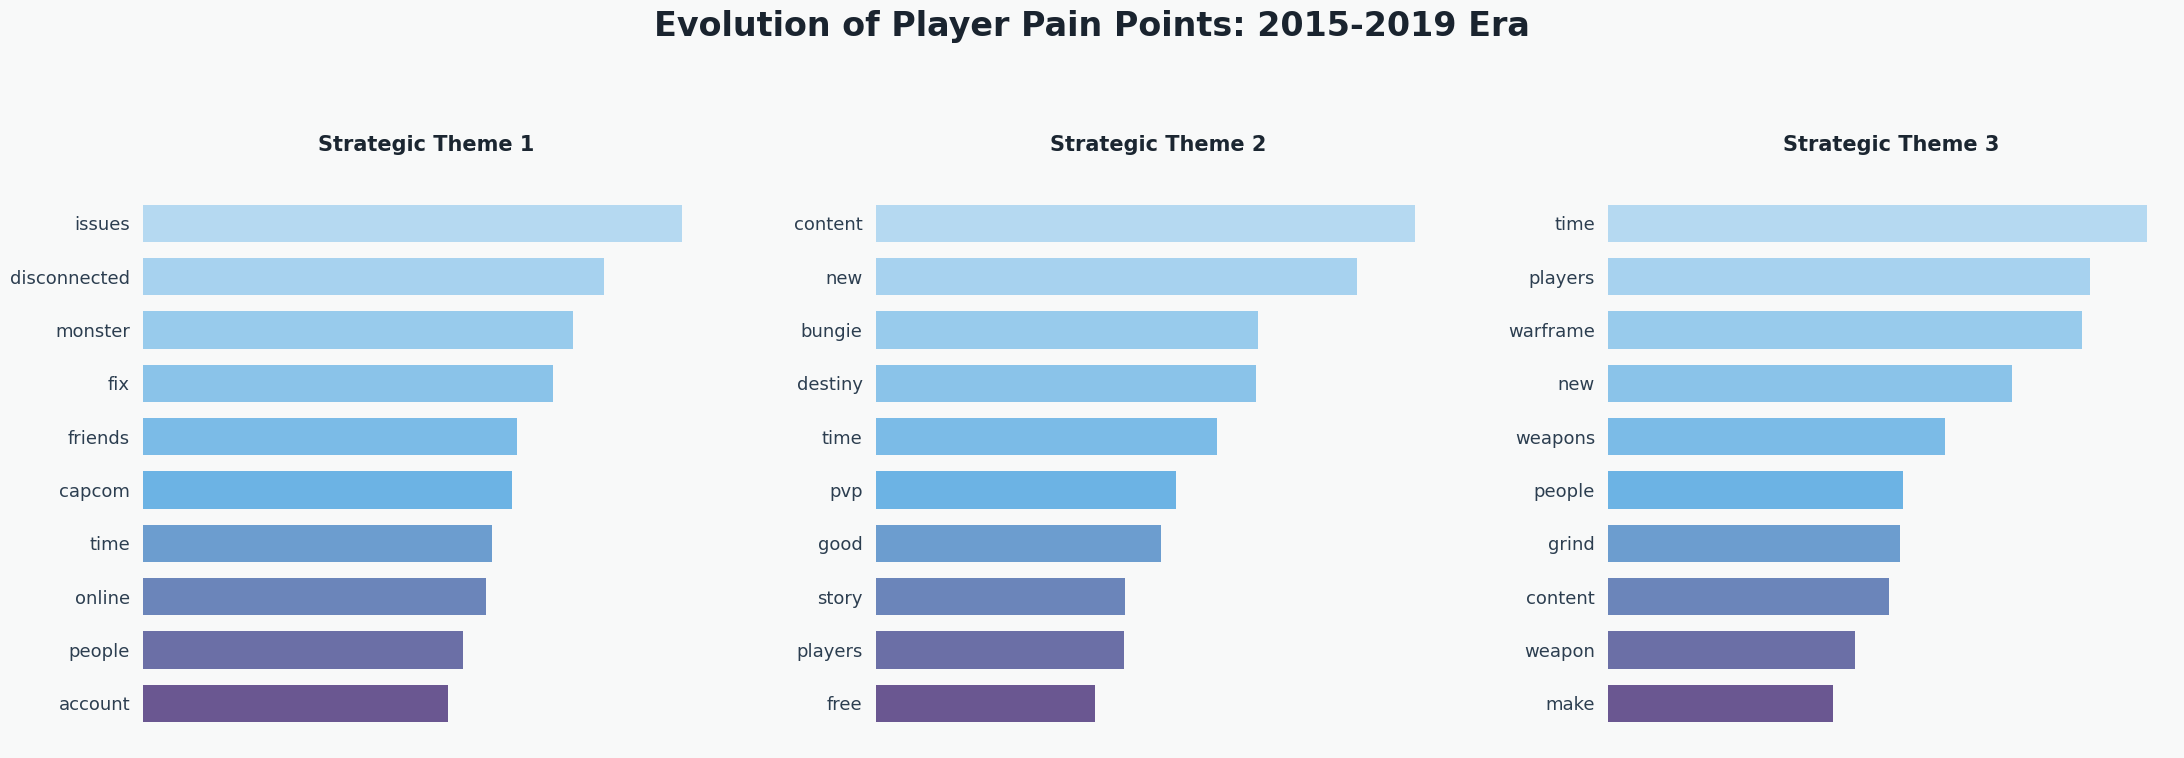

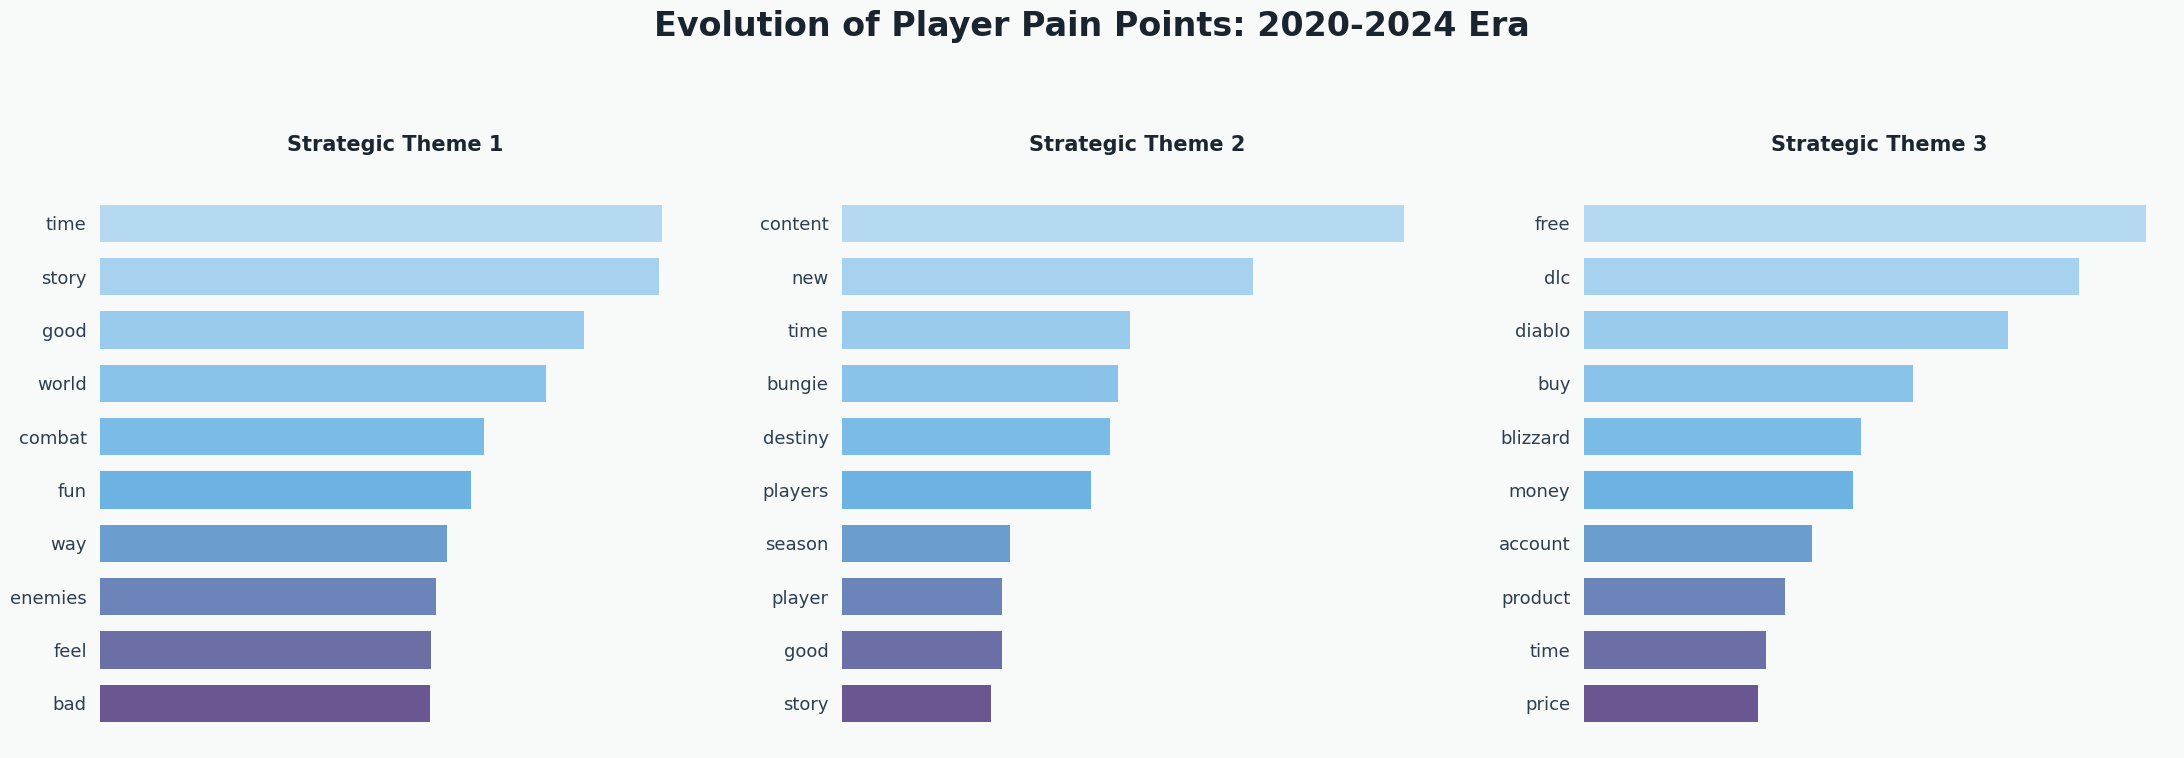

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# --- Professional Business Style Configuration ---
sns.set_theme(style="white")
plt.rcParams['figure.facecolor'] = '#F8F9F9'
plt.rcParams['axes.facecolor'] = '#F8F9F9'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# Define a Blue-Purple gradient colormap
custom_cmap = LinearSegmentedColormap.from_list("business_grad", ["#AED6F1", "#5DADE2", "#5B2C6F"])

for period in periods:
    if period not in period_topics_data:
        continue

    # Create canvas with light gray background
    fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor='#F8F9F9')
    topics = period_topics_data[period]

    for j in range(3):
        data = topics[j]
        ax = axes[j]

        # Prepare and sort data
        words = data['words']
        weights = data['weights']
        y_pos = np.arange(len(words))

        # Generate gradient colors for bars
        colors = [custom_cmap(i/len(words)) for i in range(len(words))]

        # Plot horizontal bars with slender height for a modern look
        bars = ax.barh(y_pos, weights, color=colors, height=0.7, edgecolor='none', alpha=0.9)

        # Format Y-axis with bold words and clean labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=13, fontweight='500', color='#2C3E50')
        ax.invert_yaxis()

        # Set subtitle for each strategic theme
        ax.set_title(f"Strategic Theme {j+1}", fontsize=15, fontweight='bold', pad=20, color='#1B2631')

        # Optimization: remove borders and add subtle vertical grid lines
        sns.despine(ax=ax, top=True, right=True, left=True, bottom=True)
        ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#AEB6BF')
        ax.set_axisbelow(True)

        # Remove X-axis ticks for maximum cleanliness
        ax.set_xticks([])

    # Center-aligned bold main title
    plt.suptitle(f"Evolution of Player Pain Points: {period} Era",
                 fontsize=24, fontweight='bold', y=1.08, color='#1A242F')

    plt.tight_layout(w_pad=4) # Increase spacing for visual 'breathing room'
    plt.show()

### **Executive Summary: The Evolution of Player Dissatisfaction (2010–2024)**

This longitudinal analysis of the RPG genre reveals a significant shift in the drivers of negative player sentiment over the past 14 years. By segmenting player reviews into three distinct eras, we identify a clear transition in consumer expectations and industry pain points:

*   **2010–2014: Infrastructure & Systemic Hurdles**  
    Early dissatisfaction was primarily rooted in technical accessibility and account management. Players focused on the friction of entry, such as account support and foundational 'grind' mechanics, indicating an era defined by building basic live-service stability.

*   **2015–2019: Connectivity & Content Delivery**  
    As the genre moved toward persistent online worlds, the narrative shifted to network reliability. Issues regarding server stability and the pacing of 'post-launch' content became the primary sources of frustration, highlighting the challenges of maintaining long-term player engagement.

*   **2020–2024: Business Models & Narrative Quality**  
    In the modern era, dissatisfaction has become more sophisticated. The focus has moved toward the 'fairness' of monetization strategies (DLC pricing) and the execution of expansive game worlds. Even top-tier titles face backlash when the perceived value proposition does not align with monetization or when open-world scope compromises narrative depth.

**Strategic Recommendation:** To address modern dissatisfaction, developers should shift focus from expanding the sheer size of game worlds toward optimizing value transparency and narrative flow, as today’s players are more critical of business ethics and quality-of-time than technical connectivity.

### **Total Negative Feedback Volume: Absolute Scale (2010–2024)**
While the *proportion* of complaints shifts, the *absolute volume* of negative feedback has grown exponentially. This demonstrates the increasing scale of community management and support infrastructure required in the modern era.

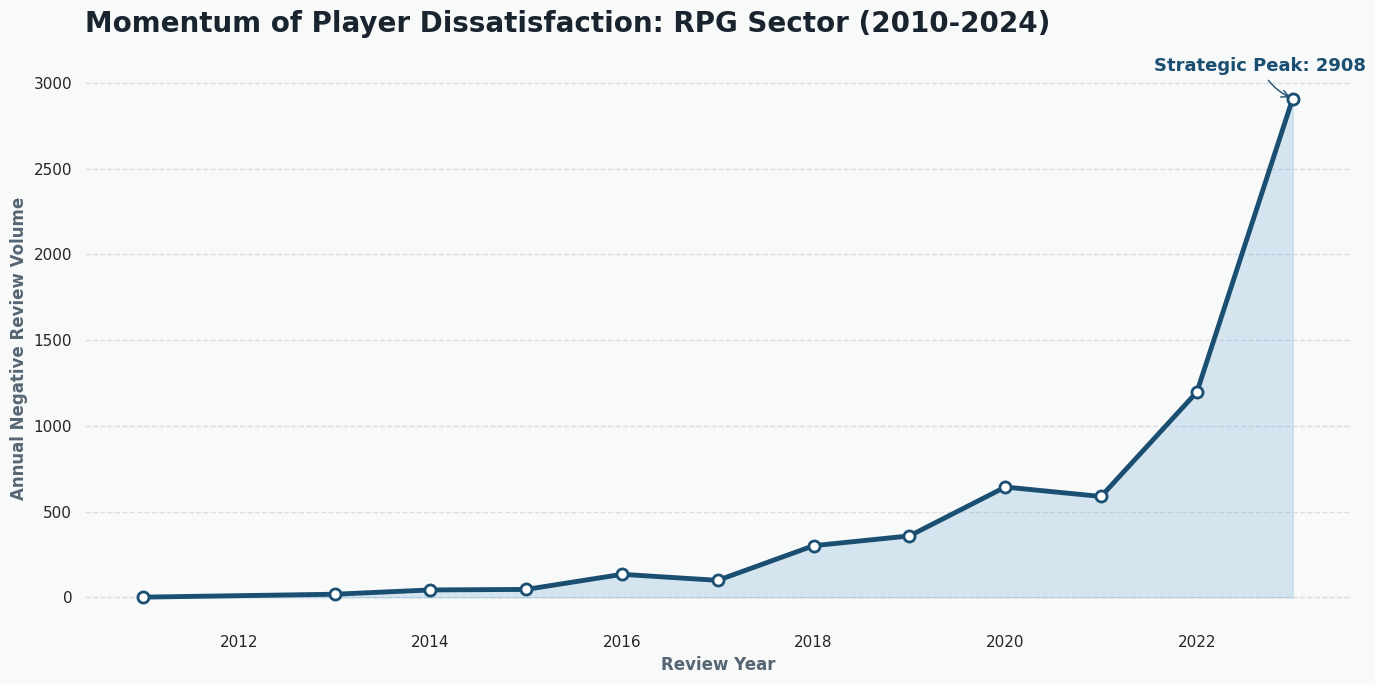

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Prepare Data
volume_trend = df_rpg_neg.groupby('review_year').size().reset_index(name='count')
plot_data = volume_trend[volume_trend['review_year'] >= 2010]

# 2. Premium Styling Configuration
plt.figure(figsize=(14, 7), facecolor='#F8F9F9')
sns.set_style("white", {'axes.facecolor': '#F8F9F9'})

# 3. Create Gradient Area Plot
x = plot_data['review_year']
y = plot_data['count']

# Fill with a soft gradient
plt.fill_between(x, y, color='#2E86C1', alpha=0.15)
plt.fill_between(x, y, color='#AED6F1', alpha=0.1, where=(y > 0))

# Main sophisticated line with a 'glow' effect
plt.plot(x, y, color='#1B4F72', linewidth=3.5, marker='o', markersize=8,
         markerfacecolor='white', markeredgewidth=2, label='Total Negative Feedback')

# 4. Refined Typography and Labels
plt.title('Momentum of Player Dissatisfaction: RPG Sector (2010-2024)',
          fontsize=20, fontweight='bold', pad=30, color='#1A242F', loc='left')

plt.ylabel('Annual Negative Review Volume', fontsize=12, fontweight='600', color='#566573')
plt.xlabel('Review Year', fontsize=12, fontweight='600', color='#566573')

# Clean up the spines
sns.despine(left=True, bottom=True)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='#AEB6BF')

# 5. Strategic Annotation
peak_year = plot_data.loc[plot_data['count'].idxmax(), 'review_year']
peak_val = plot_data['count'].max()

plt.annotate(f'Strategic Peak: {int(peak_val)}',
             xy=(peak_year, peak_val),
             xytext=(-100, 20), textcoords='offset points',
             fontsize=13, fontweight='bold', color='#1B4F72',
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=.2', color='#1B4F72'))

plt.tight_layout()
plt.show()